# Median Filtering for Salt and Pepper Noise Removal

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import random
from skimage import metrics
import os

In [ ]:
def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    noisy_image = image.copy()

    # Generate random matrix
    random_matrix = np.random.random(image.shape[:2])

    # Add salt noise (white pixels)
    salt_mask = random_matrix < salt_prob
    if len(image.shape) == 3:  # Color image
        noisy_image[salt_mask] = [255, 255, 255]
    else:  # Grayscale image
        noisy_image[salt_mask] = 255

    # Add pepper noise (black pixels)
    pepper_mask = (random_matrix > (1 - pepper_prob))
    if len(image.shape) == 3:  # Color image
        noisy_image[pepper_mask] = [0, 0, 0]
    else:  # Grayscale image
        noisy_image[pepper_mask] = 0

    return noisy_image

In [ ]:
def median_filter_manual(image, kernel_size=3):
    if kernel_size % 2 == 0:
        raise ValueError("Kernel size must be odd")

    # Padding
    pad = kernel_size // 2
    if len(image.shape) == 3:  # Color image
        padded_image = np.pad(image, ((pad, pad), (pad, pad), (0, 0)), mode='edge')
        filtered_image = np.zeros_like(image)

        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                for c in range(image.shape[2]):
                    # Extract neighborhood
                    neighborhood = padded_image[i:i+kernel_size, j:j+kernel_size, c]
                    # Apply median filter
                    filtered_image[i, j, c] = np.median(neighborhood)
    else:  # Grayscale image
        padded_image = np.pad(image, pad, mode='edge')
        filtered_image = np.zeros_like(image)

        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                # Extract neighborhood
                neighborhood = padded_image[i:i+kernel_size, j:j+kernel_size]
                # Apply median filter
                filtered_image[i, j] = np.median(neighborhood)

    return filtered_image.astype(np.uint8)

In [ ]:
def calculate_metrics(original, processed):
    # Convert to grayscale if color image
    if len(original.shape) == 3:
        orig_gray = cv2.cvtColor(original, cv2.COLOR_RGB2GRAY)
        proc_gray = cv2.cvtColor(processed, cv2.COLOR_RGB2GRAY)
    else:
        orig_gray = original
        proc_gray = processed

    # Calculate MSE
    mse = np.mean((orig_gray - proc_gray) ** 2)

    # Calculate PSNR
    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 20 * np.log10(255.0 / np.sqrt(mse))

    return {'PSNR': psnr, 'MSE': mse}

In [10]:
# Load image
original_image = cv2.imread('../../input.jpg')
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

# Resize image if too large
if original_image.shape[0] > 400 or original_image.shape[1] > 400:
    height, width = original_image.shape[:2]
    scale = min(400/height, 400/width)
    new_height = int(height * scale)
    new_width = int(width * scale)
    original_image = cv2.resize(original_image, (new_width, new_height))

print(f"Image shape: {original_image.shape}")

Image shape: (266, 400, 3)


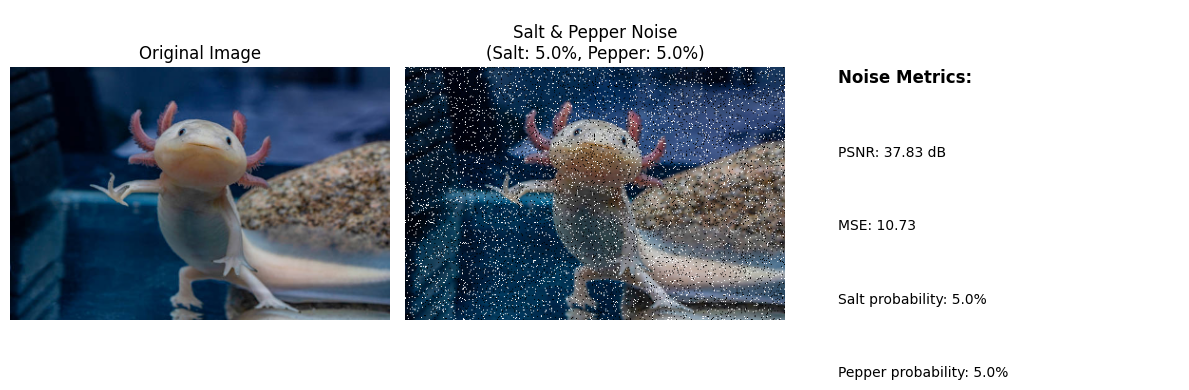

In [11]:
# Add salt and pepper noise
salt_prob = 0.05
pepper_prob = 0.05
noisy_image = add_salt_pepper_noise(original_image, salt_prob, pepper_prob)

# Display comparison
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noisy_image)
plt.title(f'Salt & Pepper Noise\n(Salt: {salt_prob*100}%, Pepper: {pepper_prob*100}%)')
plt.axis('off')

noise_metrics = calculate_metrics(original_image, noisy_image)
plt.subplot(1, 3, 3)
plt.text(0.1, 0.8, f'Noise Metrics:', fontsize=12, weight='bold')
plt.text(0.1, 0.6, f'PSNR: {noise_metrics["PSNR"]:.2f} dB', fontsize=10)
plt.text(0.1, 0.4, f'MSE: {noise_metrics["MSE"]:.2f}', fontsize=10)
plt.text(0.1, 0.2, f'Salt probability: {salt_prob*100}%', fontsize=10)
plt.text(0.1, 0.0, f'Pepper probability: {pepper_prob*100}%', fontsize=10)
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Apply manual median filter with different kernel sizes
kernel_sizes = [3, 5, 7]
filtered_images = {}
metrics_data = {}

for kernel_size in kernel_sizes:
    filtered_manual = median_filter_manual(noisy_image, kernel_size)
    filtered_images[f'manual_{kernel_size}x{kernel_size}'] = filtered_manual

    metrics_manual = calculate_metrics(original_image, filtered_manual)
    metrics_data[f'manual_{kernel_size}x{kernel_size}'] = metrics_manual

    print(f"Kernel size {kernel_size}x{kernel_size}:")
    print(f"  PSNR: {metrics_manual['PSNR']:.2f} dB, MSE: {metrics_manual['MSE']:.2f}")
    print()

Kernel size 3x3:
  PSNR: 40.53 dB, MSE: 5.76

Kernel size 5x5:
  PSNR: 37.37 dB, MSE: 11.93

Kernel size 5x5:
  PSNR: 37.37 dB, MSE: 11.93

Kernel size 7x7:
  PSNR: 35.90 dB, MSE: 16.73

Kernel size 7x7:
  PSNR: 35.90 dB, MSE: 16.73



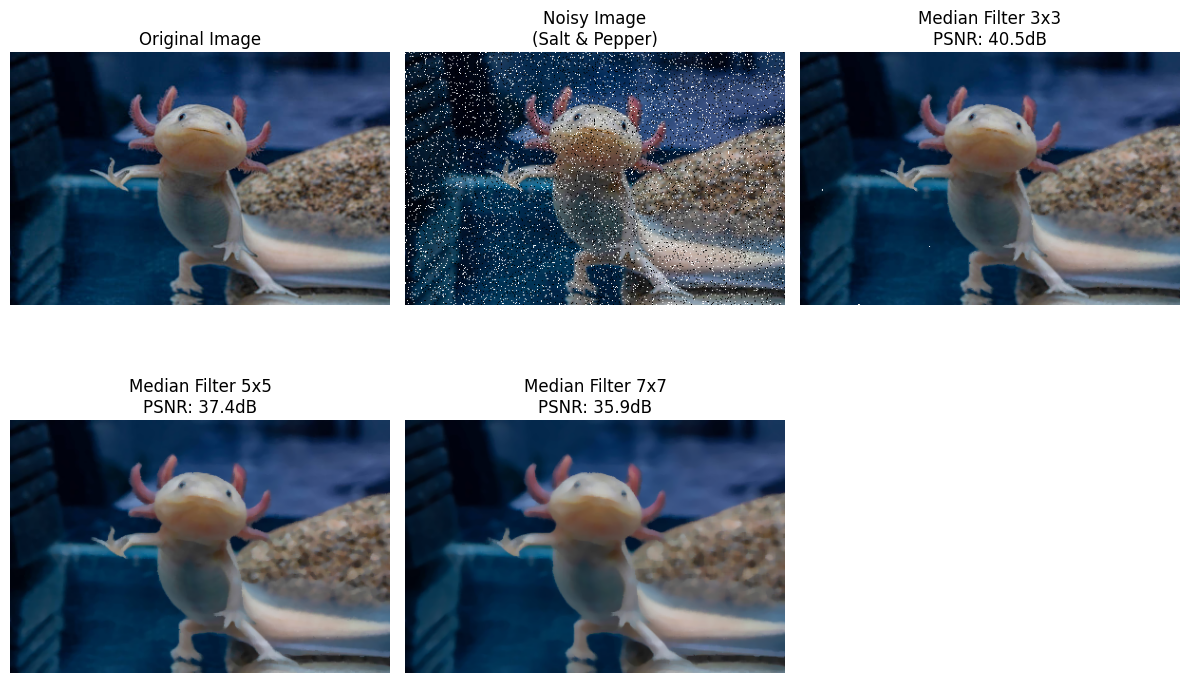

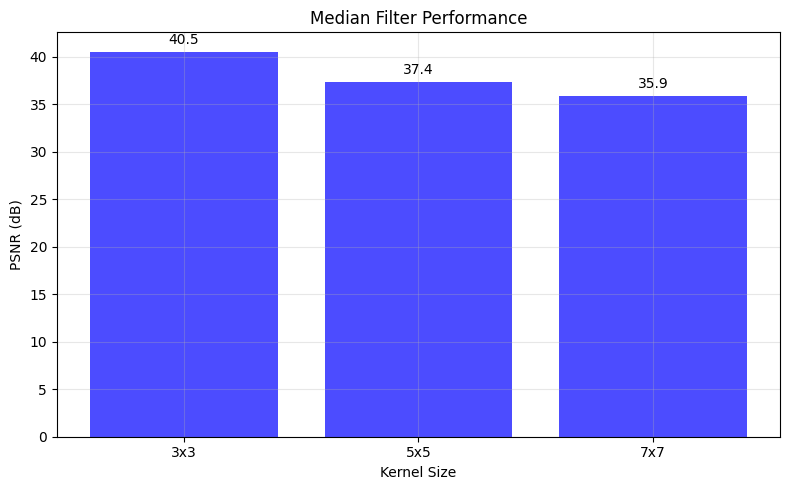

In [15]:
# Visual comparison of results
plt.figure(figsize=(12, 8))

# Original and noisy images
plt.subplot(2, 3, 1)
plt.imshow(original_image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(noisy_image)
plt.title('Noisy Image\n(Salt & Pepper)')
plt.axis('off')

# Manual median filter results
for i, kernel_size in enumerate(kernel_sizes):
    plt.subplot(2, 3, 3 + i)
    plt.imshow(filtered_images[f'manual_{kernel_size}x{kernel_size}'])
    metrics = metrics_data[f'manual_{kernel_size}x{kernel_size}']
    plt.title(f'Median Filter {kernel_size}x{kernel_size}\nPSNR: {metrics["PSNR"]:.1f}dB')
    plt.axis('off')

plt.tight_layout()
plt.show()

# PSNR comparison
plt.figure(figsize=(8, 5))
kernel_names = [f'{k}x{k}' for k in kernel_sizes]
psnr_values = [metrics_data[f'manual_{k}x{k}']['PSNR'] for k in kernel_sizes]

plt.bar(kernel_names, psnr_values, color='blue', alpha=0.7)
plt.xlabel('Kernel Size')
plt.ylabel('PSNR (dB)')
plt.title('Median Filter Performance')
plt.grid(True, alpha=0.3)

for i, v in enumerate(psnr_values):
    plt.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()